In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/unsdsn/world-happiness/2015.csv
/kaggle/input/datasets/organizations/unsdsn/world-happiness/2017.csv
/kaggle/input/datasets/organizations/unsdsn/world-happiness/2019.csv
/kaggle/input/datasets/organizations/unsdsn/world-happiness/2018.csv
/kaggle/input/datasets/organizations/unsdsn/world-happiness/2016.csv


In [8]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/organizations/unsdsn/world-happiness/2015.csv
/kaggle/input/datasets/organizations/unsdsn/world-happiness/2017.csv
/kaggle/input/datasets/organizations/unsdsn/world-happiness/2019.csv
/kaggle/input/datasets/organizations/unsdsn/world-happiness/2018.csv
/kaggle/input/datasets/organizations/unsdsn/world-happiness/2016.csv


In [9]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load all years
df2015 = pd.read_csv('/kaggle/input/datasets/organizations/unsdsn/world-happiness/2015.csv')
df2016 = pd.read_csv('/kaggle/input/datasets/organizations/unsdsn/world-happiness/2016.csv')
df2017 = pd.read_csv('/kaggle/input/datasets/organizations/unsdsn/world-happiness/2017.csv')
df2018 = pd.read_csv('/kaggle/input/datasets/organizations/unsdsn/world-happiness/2018.csv')
df2019 = pd.read_csv('/kaggle/input/datasets/organizations/unsdsn/world-happiness/2019.csv')

print("2015 shape:", df2015.shape)
print("2019 shape:", df2019.shape)
print("\n2019 Columns:", df2019.columns.tolist())
df2019.head()

2015 shape: (158, 12)
2019 shape: (156, 9)

2019 Columns: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


/tmp/ipykernel_55/2460449262.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score', y='Country or region', data=top10, palette='viridis')


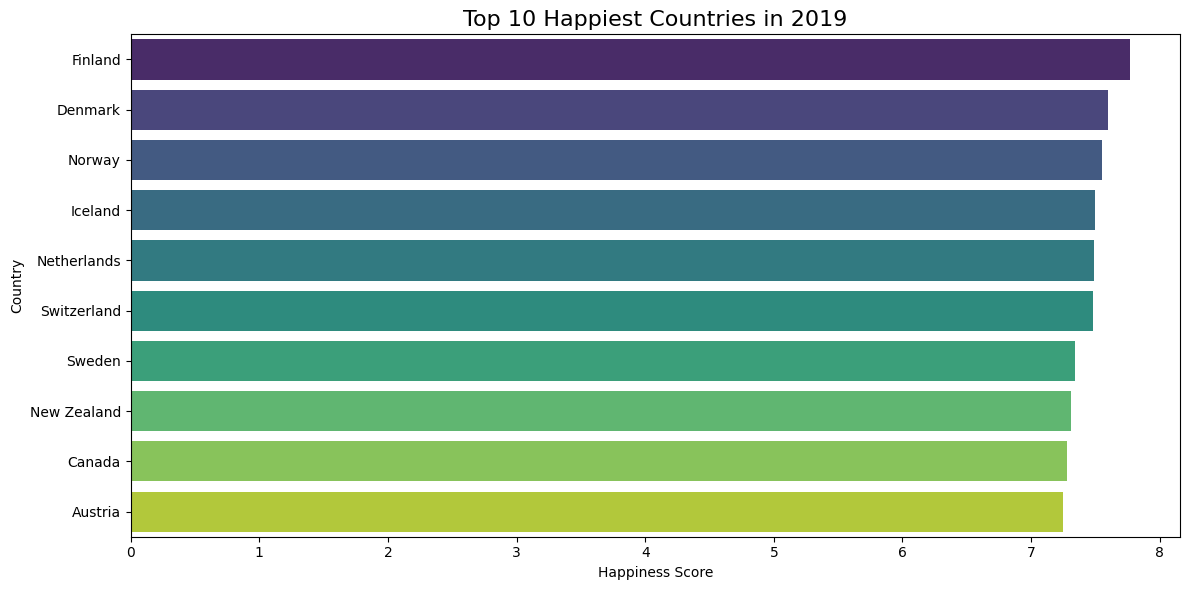

In [10]:
# Step 2: Top 10 Happiest Countries in 2019
plt.figure(figsize=(12, 6))
top10 = df2019.head(10)
sns.barplot(x='Score', y='Country or region', data=top10, palette='viridis')
plt.title('Top 10 Happiest Countries in 2019', fontsize=16)
plt.xlabel('Happiness Score')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

/tmp/ipykernel_55/1682251078.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score', y='Country or region', data=bottom10, palette='Reds_r')


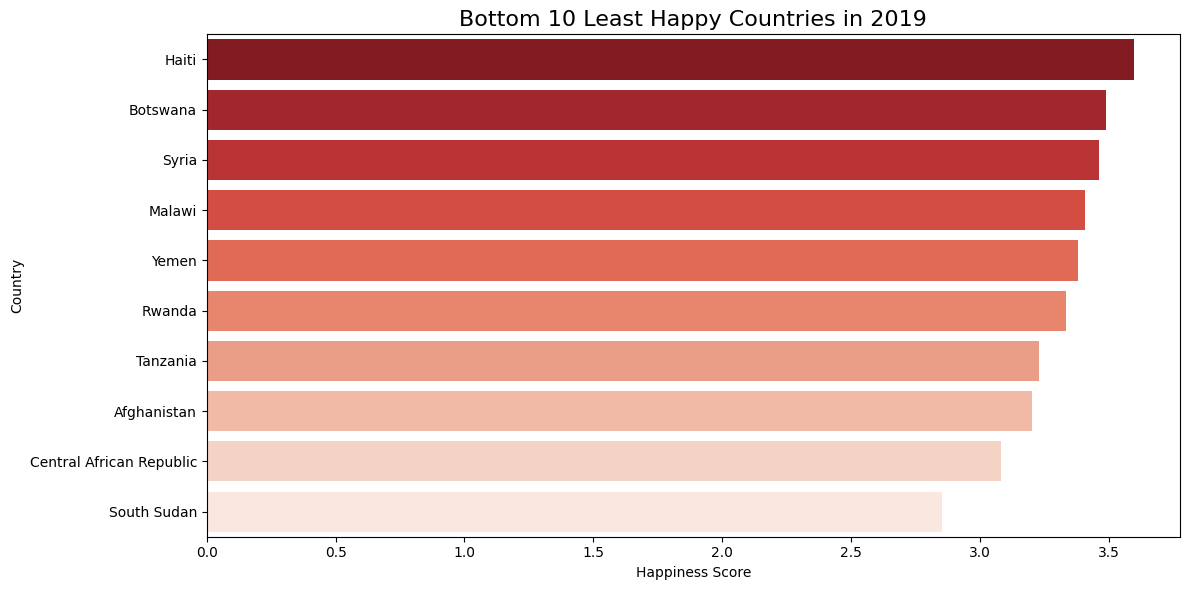

In [11]:
# Step 3: Bottom 10 Least Happy Countries in 2019
plt.figure(figsize=(12, 6))
bottom10 = df2019.tail(10)
sns.barplot(x='Score', y='Country or region', data=bottom10, palette='Reds_r')
plt.title('Bottom 10 Least Happy Countries in 2019', fontsize=16)
plt.xlabel('Happiness Score')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

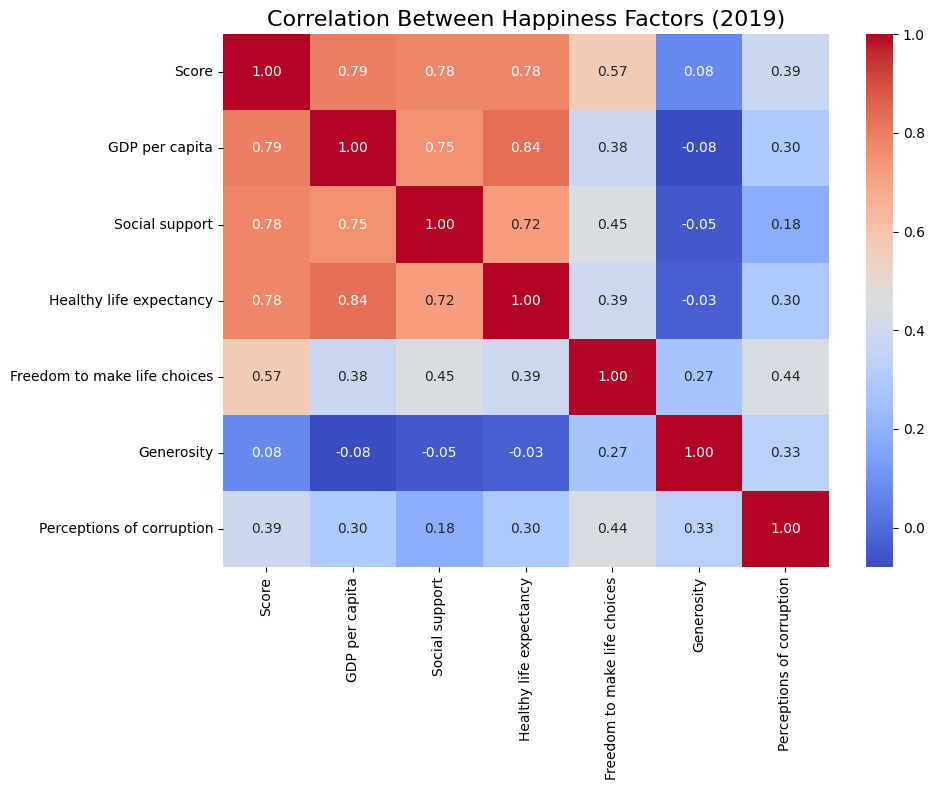

In [12]:
# Step 4: Correlation Heatmap
plt.figure(figsize=(10, 8))
cols = ['Score', 'GDP per capita', 'Social support', 
        'Healthy life expectancy', 'Freedom to make life choices', 
        'Generosity', 'Perceptions of corruption']
correlation = df2019[cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Happiness Factors (2019)', fontsize=16)
plt.tight_layout()
plt.show()

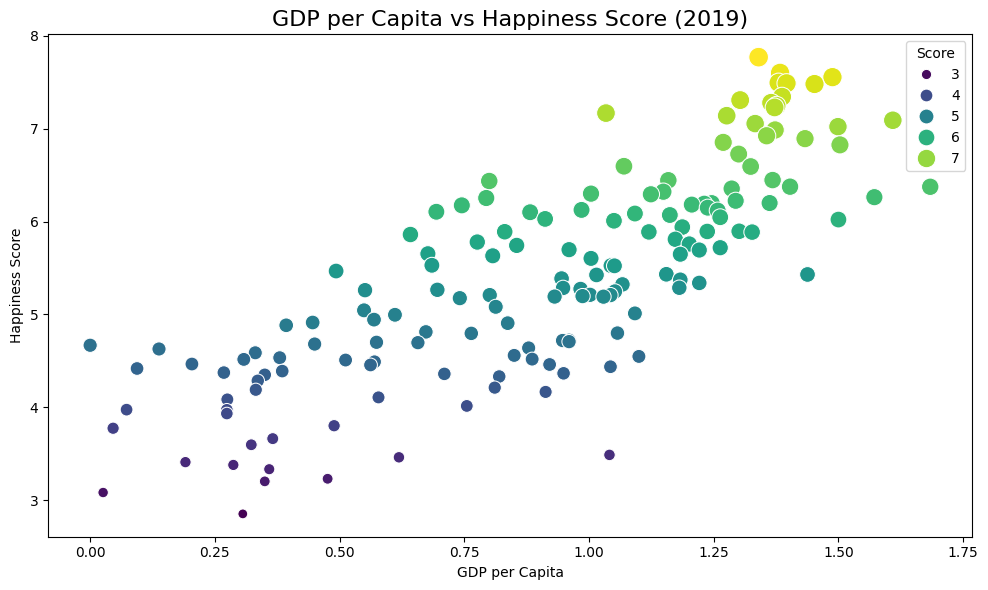

In [13]:
# Step 5: GDP vs Happiness Score scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GDP per capita', y='Score', 
                data=df2019, hue='Score', 
                palette='viridis', size='Score', sizes=(50, 200))
plt.title('GDP per Capita vs Happiness Score (2019)', fontsize=16)
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')
plt.tight_layout()
plt.show()

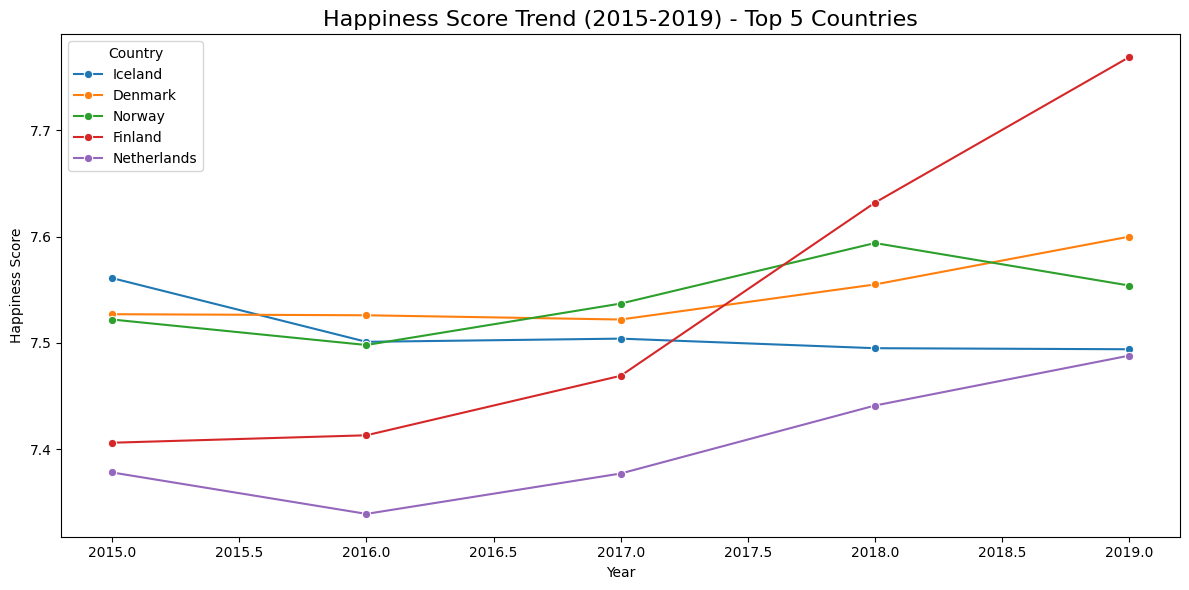

In [14]:
# Step 6: Happiness Score trend across years for Top 5 countries
# Standardize column names
df2015_clean = df2015[['Country', 'Happiness Score']].rename(columns={'Country': 'Country', 'Happiness Score': 'Score'})
df2015_clean['Year'] = 2015

df2016_clean = df2016[['Country', 'Happiness Score']].rename(columns={'Country': 'Country', 'Happiness Score': 'Score'})
df2016_clean['Year'] = 2016

df2017_clean = df2017[['Country', 'Happiness.Score']].rename(columns={'Country': 'Country', 'Happiness.Score': 'Score'})
df2017_clean['Year'] = 2017

df2018_clean = df2018[['Country or region', 'Score']].rename(columns={'Country or region': 'Country'})
df2018_clean['Year'] = 2018

df2019_clean = df2019[['Country or region', 'Score']].rename(columns={'Country or region': 'Country'})
df2019_clean['Year'] = 2019

# Combine all years
df_all = pd.concat([df2015_clean, df2016_clean, df2017_clean, df2018_clean, df2019_clean])

# Top 5 countries from 2019
top5 = df2019.head(5)['Country or region'].tolist()
df_top5 = df_all[df_all['Country'].isin(top5)]

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Score', hue='Country', data=df_top5, marker='o')
plt.title('Happiness Score Trend (2015-2019) - Top 5 Countries', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Happiness Score')
plt.tight_layout()
plt.show()

In [15]:
# Step 7: Key Insights Summary
print("=" * 50)
print("WORLD HAPPINESS REPORT - KEY INSIGHTS")
print("=" * 50)

print("\n🏆 Top 5 Happiest Countries in 2019:")
for i, row in df2019.head(5).iterrows():
    print(f"  {row['Overall rank']}. {row['Country or region']} - Score: {row['Score']}")

print("\n😔 Bottom 5 Least Happy Countries in 2019:")
for i, row in df2019.tail(5).iterrows():
    print(f"  {row['Overall rank']}. {row['Country or region']} - Score: {row['Score']}")

print("\n📊 Average Happiness Score 2019:", round(df2019['Score'].mean(), 3))
print("📊 Highest Score:", df2019['Score'].max(), "-", df2019.iloc[0]['Country or region'])
print("📊 Lowest Score:", df2019['Score'].min(), "-", df2019.iloc[-1]['Country or region'])

print("\n🔑 Strongest Correlation with Happiness:")
corr = df2019[cols].corr()['Score'].drop('Score').sort_values(ascending=False)
for factor, value in corr.items():
    print(f"  {factor}: {round(value, 3)}")

WORLD HAPPINESS REPORT - KEY INSIGHTS

🏆 Top 5 Happiest Countries in 2019:
  1. Finland - Score: 7.769
  2. Denmark - Score: 7.6
  3. Norway - Score: 7.554
  4. Iceland - Score: 7.494
  5. Netherlands - Score: 7.488

😔 Bottom 5 Least Happy Countries in 2019:
  152. Rwanda - Score: 3.334
  153. Tanzania - Score: 3.231
  154. Afghanistan - Score: 3.203
  155. Central African Republic - Score: 3.083
  156. South Sudan - Score: 2.853

📊 Average Happiness Score 2019: 5.407
📊 Highest Score: 7.769 - Finland
📊 Lowest Score: 2.853 - South Sudan

🔑 Strongest Correlation with Happiness:
  GDP per capita: 0.794
  Healthy life expectancy: 0.78
  Social support: 0.777
  Freedom to make life choices: 0.567
  Perceptions of corruption: 0.386
  Generosity: 0.076
